In [89]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder



In [90]:
df = pd.read_csv('titanic_data_updated.csv')
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [92]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [93]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [94]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [95]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

<Axes: xlabel='Age', ylabel='Density'>

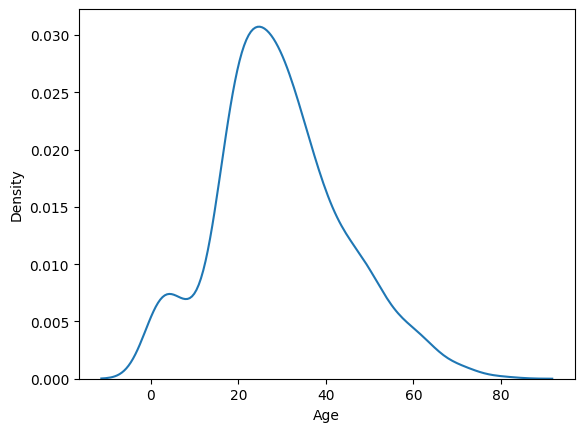

In [96]:
sns.kdeplot(data=df['Age'])

In [97]:
age_mean = df['Age'].mean()
age_mean

np.float64(29.69911764705882)

In [98]:
age_median = df['Age'].median()
age_median

np.float64(28.0)

In [99]:
x = df.drop(['Survived'], axis=1)
y = df['Survived']
display(x)
display(y)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [100]:
x.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [101]:
y.isnull().sum()

np.int64(0)

In [102]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [103]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [104]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


In [105]:
y_train

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [106]:
y_test

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

In [107]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [108]:
y_train.isnull().sum()

np.int64(0)

In [109]:
age_mean 
age_median 

np.float64(28.0)

In [110]:
age_mean_impute = x_train['Age'].mean()
x_train['age_mean_impute'] = x_train['Age'].fillna(age_mean_impute)
x_test['age_mean_impute'] = x_test['Age'].fillna(age_mean_impute)


In [111]:
age_median_impute = x_train['Age'].median()
x_train['age_median_impute'] = x_train['Age'].fillna(age_median_impute)
x_test['age_median_impute'] = x_test['Age'].fillna(age_median_impute)

<Axes: xlabel='age_mean_impute', ylabel='Density'>

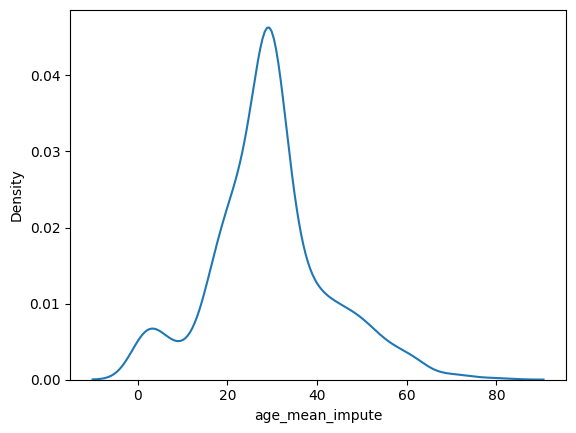

In [112]:
sns.kdeplot(data=x_train, x='age_mean_impute')

<Axes: xlabel='age_median_impute', ylabel='Density'>

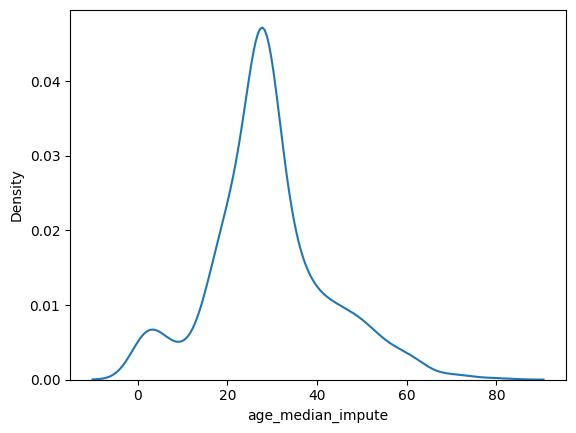

In [113]:
sns.kdeplot(data=x_train, x='age_median_impute')

In [114]:
age_imp = SimpleImputer(missing_values=np.nan, strategy='mean')
age_imp.fit(x_train[['Age']])
x_train['Age'] = age_imp.transform(x_train[['Age']]).ravel()
x_test['Age'] = age_imp.transform(x_test[['Age']]).ravel()

embarked_imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
embarked_imp.fit(x_train[['Embarked']])
x_train['Embarked'] = embarked_imp.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embarked_imp.transform(x_test[['Embarked']]).ravel()

cabin_imputer = SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)
cabin_imputer.fit(x_train[['Cabin']])
x_train[['Cabin','cabin_missing_indicator']]= cabin_imputer.transform(x_train[['Cabin']])
x_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(x_test[['Cabin']])

x_train.drop(['age_median_impute', 'age_mean_impute'], axis=1, inplace=True)
x_test.drop(['age_median_impute', 'age_mean_impute'], axis=1, inplace=True)


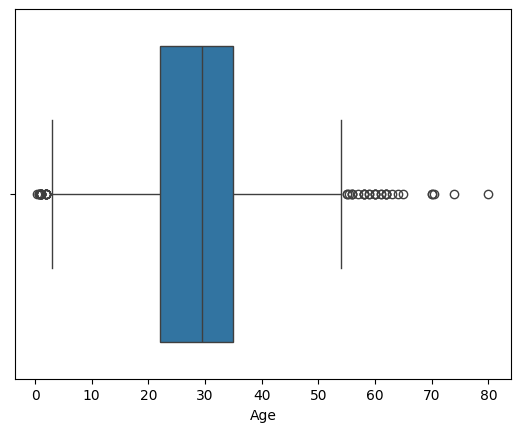

In [115]:
# age outliers 

sns.boxplot(data=x_train, x='Age')
plt.show()

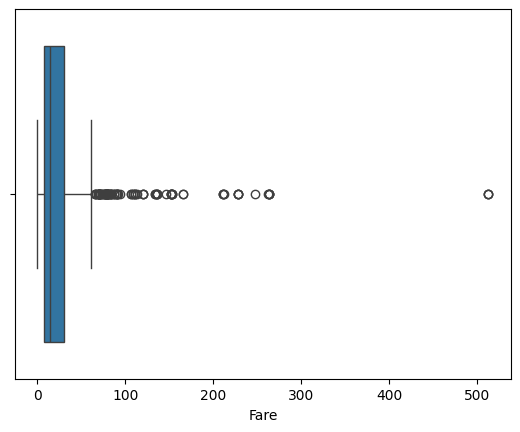

In [116]:
# fare outliers

# sns.kdeplot(data=x_train, x='Fare')
sns.boxplot(data=x_train, x='Fare')

plt.show()

In [117]:
q1 = x_train['Fare'].quantile(0.25)
q3 = x_train['Fare'].quantile(0.75)
iqr = q3 - q1

left_side = max(0, q1 - 1.5 * iqr)
right_side = q3 + 1.5 * iqr

# cap 
x_train['Fare'] = x_train['Fare'].clip(left_side, right_side)
x_test['Fare'] = x_test['Fare'].clip(left_side, right_side)


print(left_side)
print(right_side)
print(iqr)
print(q1, q3)

0
64.3625
22.575
7.925 30.5


In [118]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False


<Axes: xlabel='Age', ylabel='Density'>

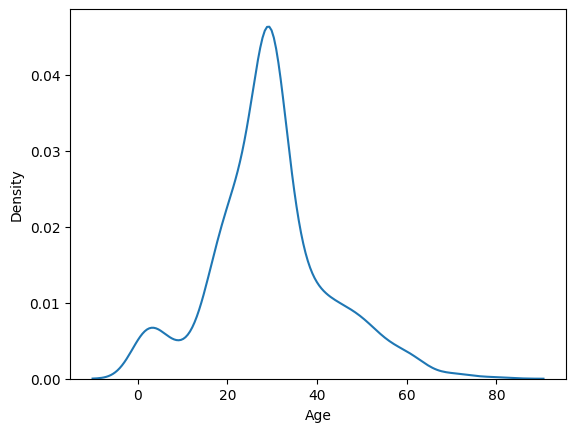

In [119]:
sns.kdeplot(data=x_train, x='Age')

<Axes: xlabel='Age', ylabel='Density'>

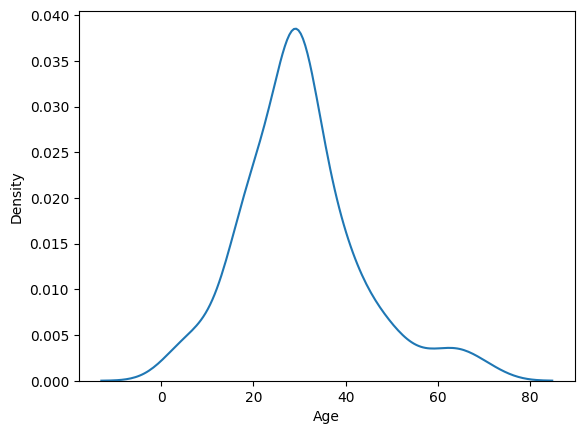

In [120]:
sns.kdeplot(data=x_test, x='Age')


In [121]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Pclass                   712 non-null    object 
 1   Sex                      712 non-null    object 
 2   Age                      712 non-null    float64
 3   SibSp                    712 non-null    int64  
 4   Parch                    712 non-null    int64  
 5   Fare                     712 non-null    float64
 6   Cabin                    712 non-null    object 
 7   Embarked                 712 non-null    object 
 8   cabin_missing_indicator  712 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 55.6+ KB


In [122]:
# ordinal encoding

pclass_encoder = OrdinalEncoder(categories=[['third', 'second', 'first']])
pclass_encoder.fit(x_train[['Pclass']])

x_train['encoded_pclass'] = pclass_encoder.transform(x_train[['Pclass']]).ravel()
x_test['encoded_pclass'] = pclass_encoder.transform(x_test[['Pclass']]).ravel()

In [123]:
# for nomical categories (one hot encoding)

sex_1hot_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
sex_1hot_encoder.fit(x_train[['Sex']])


encoded_df = sex_1hot_encoder.transform(x_train[['Sex']])
encoded_dff = sex_1hot_encoder.transform(x_test[['Sex']])

x_train = pd.concat([x_train, encoded_df],axis=1)
x_test = pd.concat([x_test, encoded_dff],axis=1)
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,0.0,1.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,1.0,0.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,0.0,1.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,1.0,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,1.0,0.0


In [124]:
embarked_1hot_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
embarked_1hot_encoder.fit(x_train[['Embarked']])

encoded_df = embarked_1hot_encoder.transform(x_train[['Embarked']])
x_train = pd.concat([x_train, encoded_df],axis=1)

encoded_dff = embarked_1hot_encoder.transform(x_test[['Embarked']])
x_test = pd.concat([x_test, encoded_dff],axis=1)

x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,1.0,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,1.0,0.0,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,1.0,0.0,0.0,0.0,1.0


In [125]:
x_train.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)
x_test.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)


In [126]:
x_test

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,29.498846,1,1,15.2458,Missing,True,0.0,0.0,1.0,1.0,0.0,0.0
439,31.000000,0,0,10.5000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
720,6.000000,0,1,33.0000,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0
39,14.000000,1,0,11.2417,Missing,True,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
773,29.498846,0,0,7.2250,Missing,True,0.0,0.0,1.0,1.0,0.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
84,17.000000,0,0,10.5000,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0


In [127]:
x_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0


In [128]:
x_train.isnull().sum()

Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
cabin_missing_indicator    0
encoded_pclass             0
Sex_female                 0
Sex_male                   0
Embarked_C                 0
Embarked_Q                 0
Embarked_S                 0
dtype: int64

In [129]:
x_test.describe()

,Age,SibSp,Parch,Fare,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000
mean,30.297694,0.402235,0.391061,24.481215,0.776536,0.385475,0.614525,0.240223,0.094972,0.664804
std,13.050748,0.730703,0.863185,20.093118,0.877501,0.488073,0.488073,0.428417,0.293999,0.473383
min,0.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.895800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.498846,0.000000,0.000000,14.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,36.000000,1.000000,0.000000,32.410400,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,71.000000,4.000000,5.000000,64.362500,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [130]:
# cabin encoding

x_train['cabin_deck'] = x_train['Cabin'].astype(str).str[0]
x_train['cabin_deck'].value_counts()
x_test['cabin_deck'] = x_test['Cabin'].astype(str).str[0]
x_test['cabin_deck'].value_counts()

cabin_ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
cabin_ohe.fit(x_train[['cabin_deck']])

encoded_df = cabin_ohe.transform(x_train[['cabin_deck']])
encoded_dff = cabin_ohe.transform(x_test[['cabin_deck']])

x_train = pd.concat([x_train, encoded_df],axis=1)
x_test = pd.concat([x_test,encoded_dff], axis=1)

In [131]:
x_train.drop('cabin_deck',axis=1, inplace=True)
x_test.drop('cabin_deck',axis=1, inplace=True)


In [132]:
# label encoder

le = LabelEncoder()

# fit
le.fit(y_train)

# transform
ytrain = le.transform(y_train)
ytest = le.transform(y_test)

y_train_encoded = pd.Series(ytrain,index=y_train.index, name=y_train.name)
y_test_encoded = pd.Series(ytest,index=y_test.index, name=y_test.name)


In [135]:
y_train_encoded

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64